In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv('../data/raw/products.csv')
df.head(30)

,id,language,product,category
0,1,id,laptop Lenovo ThinkPad X1 Carbon Gen 11,IT
1,2,id,PC desktop Dell OptiPlex 7010 Tower,IT
2,3,id,monitor eksternal ASUS ProArt PA278CV,IT
3,4,id,mini PC ASUS ExpertCenter PN64,IT
4,5,id,router Wi-Fi kantor TP-Link Archer AX90 (AX6600),IT
5,6,id,network switch Cisco CBS250-24T-4G,IT
6,7,id,network attached storage (NAS) Synology DiskSt...,IT
7,8,id,printer multi-fungsi HP LaserJet Pro MFP M428fdn,IT
8,9,id,scanner dokumen Epson WorkForce DS-530 II,IT
9,10,id,keyboard wireless Logitech MX Keys S,IT


In [3]:
x = df['product']
y = df['category']

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [5]:
vectorizer = TfidfVectorizer()

x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

In [6]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(x_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [7]:
y_pred = model.predict(x_test_tfidf)

In [8]:
results = pd.DataFrame({
    'product': x_test,
    'actual': y_test,
    'predicted': y_pred
})

results

,product,actual,predicted
185,便携式投影仪,IT,IT
33,map tulang ukuran A4,Office Supplies,Office Supplies
58,lampu sorot tanam untuk koridor,Electrical,Electrical
37,buku agenda ukran A5,Office Supplies,IT
79,baut kecil segi enam,Tools & Hardware,Tools & Hardware
124,钢丝钳8寸,Tools & Hardware,IT
103,防降噪耳罩,Safety Equipment,IT
116,复合式洗眼器12L/min,Safety Equipment,IT
106,安全鞋耐200J冲击,Safety Equipment,IT
101,防护眼镜,Safety Equipment,IT


In [9]:
print(classification_report(y_test, y_pred))

                  precision    recall  f1-score   support

      Electrical       1.00      0.38      0.55         8
              IT       0.24      0.88      0.38         8
 Office Supplies       0.75      0.38      0.50         8
Safety Equipment       0.50      0.12      0.20         8
Tools & Hardware       1.00      0.25      0.40         8

        accuracy                           0.40        40
       macro avg       0.70      0.40      0.40        40
    weighted avg       0.70      0.40      0.40        40



In [10]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

cm

array([[3, 4, 0, 1, 0],
       [0, 7, 1, 0, 0],
       [0, 5, 3, 0, 0],
       [0, 7, 0, 1, 0],
       [0, 6, 0, 0, 2]])

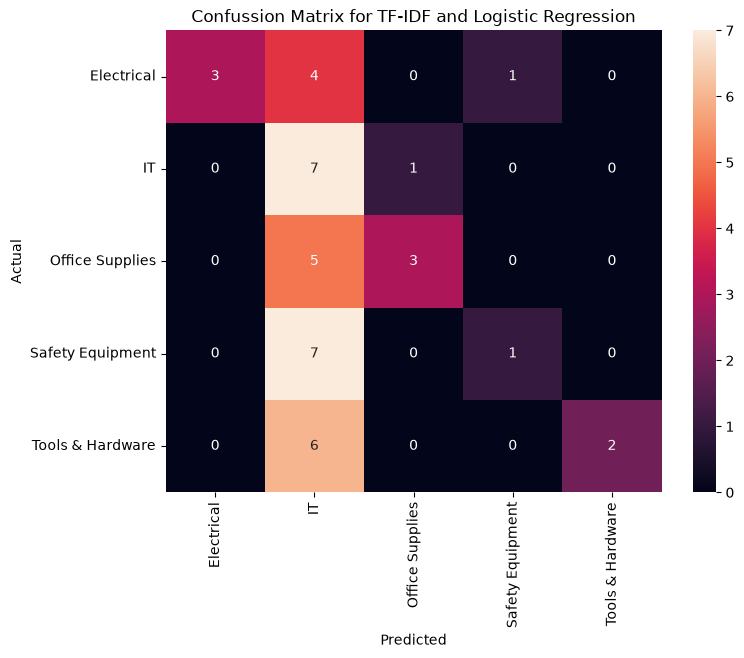

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confussion Matrix for TF-IDF and Logistic Regression')

plt.show()

In [12]:
baseline_accuracy = accuracy_score(y_test, y_pred)

print(f'Baseline Accuracy: {baseline_accuracy:.3f}')

Baseline Accuracy: 0.400


In [13]:
from sklearn.metrics import f1_score

baseline_macro_f1 = f1_score(
    y_test,
    y_pred,
    average='macro'
)

print(f'Baseline Macro-F1： {baseline_macro_f1:.3f}')

Baseline Macro-F1： 0.405


In [14]:
errors = results[
    results['actual'] != results['predicted']
]

errors

,product,actual,predicted
37,buku agenda ukran A5,Office Supplies,IT
124,钢丝钳8寸,Tools & Hardware,IT
103,防降噪耳罩,Safety Equipment,IT
116,复合式洗眼器12L/min,Safety Equipment,IT
106,安全鞋耐200J冲击,Safety Equipment,IT
101,防护眼镜,Safety Equipment,IT
102,防噪音耳塞,Safety Equipment,IT
162,荧光笔,Office Supplies,IT
54,alat pemantau suhu dan kelembapan,Electrical,Safety Equipment
163,白板笔,Office Supplies,IT


In [15]:
errors.sort_values(
    ['actual','predicted']
)

,product,actual,predicted
142,智能电视4K超高清,Electrical,IT
158,电力测仪,Electrical,IT
140,智能手机6.7 英寸 OLED,Electrical,IT
148,电热水壶,Electrical,IT
54,alat pemantau suhu dan kelembapan,Electrical,Safety Equipment
17,fingerprint dan akses kontrol Secure X100-C,IT,Office Supplies
37,buku agenda ukran A5,Office Supplies,IT
162,荧光笔,Office Supplies,IT
163,白板笔,Office Supplies,IT
160,签字笔,Office Supplies,IT


In [16]:
feature_names = vectorizer.get_feature_names_out()

for i, category in enumerate(model.classes_):
    coefficients = model.coef_[i]

    top_indices = coefficients.argsort()[-10:][::-1]

    print(category)

    for index in top_indices:
        print(
            feature_names[index],
            round(coefficients[index], 3)
        )

Electrical
lampu 0.982
kabel 0.842
led 0.794
微波炉 0.644
电动牙刷 0.644
滚筒洗衣机 0.644
家用冰箱500升 0.644
吹风机 0.644
无线蓝牙耳机 0.644
数码相机全画幅 0.644
IT
ups 0.724
标签打印机 0.638
加密移动硬盘 0.638
激光多功能一体机 0.638
高速文档扫描仪 0.638
企业级网络存储nas 0.638
企业级无线路由器 0.638
企业级交换机 0.638
人体工学键鼠套装 0.638
商务降噪耳机 0.638
Office Supplies
kertas 1.491
spidol 0.793
文件袋 0.646
无线装订本b5 0.646
hb六角木制铅笔 0.646
回形针 0.646
档案盒 0.646
复印纸 0.646
打孔机 0.646
笔记本横线本 0.646
Safety Equipment
telinga 0.786
sarung 0.772
tangan 0.663
respirator 0.656
灭火毯 0.64
灭火器4kg 0.64
缓冲安全绳 0.64
急救箱 0.64
安全标识牌 0.64
反光背心120g经编布 0.64
Tools & Hardware
meteran 0.789
gergaji 0.727
kunci 0.706
set 0.706
bor 0.696
游标卡尺数显 0.642
电工胶带600v 0.642
水平尺带磁性 0.642
电钻750w 0.642
活动扳手10寸 0.642


# Character-level TF-IDF

In [17]:
char_vectorizer = TfidfVectorizer(
    analyzer='char',
    ngram_range=(2, 5),
    min_df=1
)

In [18]:
x_train_char = char_vectorizer.fit_transform(x_train)
x_test_char = char_vectorizer.transform(x_test)

In [19]:
char_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

char_model.fit(x_train_char, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [20]:
y_pred_char = char_model.predict(x_test_char)

In [21]:
char_accuracy = accuracy_score(y_test, y_pred_char)

char_macro_f1 = f1_score(
    y_test,
    y_pred_char,
    average='macro'
)

print(f'Character TF-IDF Accuracy: {char_accuracy:.3f}')
print(f'Character TF-IDF Macro-F1: {char_macro_f1:.3f}')

Character TF-IDF Accuracy: 0.450
Character TF-IDF Macro-F1: 0.452


In [22]:
comparison = pd.DataFrame({
    'Model': [
        'Word TF-IDF + Logistic Regression',
        'Character TF-IDF + Logistic Regression'
    ],
    'Accuracy': [
        baseline_accuracy,
        char_accuracy
    ],
    'Macro-F1': [
        baseline_macro_f1,
        char_macro_f1
    ]
})

comparison

,Model,Accuracy,Macro-F1
0,Word TF-IDF + Logistic Regression,0.40,0.404767
1,Character TF-IDF + Logistic Regression,0.45,0.451573


In [26]:
char_results = pd.DataFrame({
    'product': x_test,
    'actual': y_test,
    'predicted': y_pred_char
})

char_errors = char_results[
    char_results['actual'] != char_results['predicted']
]

char_errors

,product,actual,predicted
185,便携式投影仪,IT,Electrical
33,map tulang ukuran A4,Office Supplies,Safety Equipment
37,buku agenda ukran A5,Office Supplies,Tools & Hardware
79,baut kecil segi enam,Tools & Hardware,Office Supplies
103,防降噪耳罩,Safety Equipment,IT
102,防噪音耳塞,Safety Equipment,Tools & Hardware
162,荧光笔,Office Supplies,Tools & Hardware
54,alat pemantau suhu dan kelembapan,Electrical,Safety Equipment
163,白板笔,Office Supplies,Tools & Hardware
65,tang kombinasi,Tools & Hardware,Safety Equipment


In [27]:
char_cm = confusion_matrix(
    y_test,
    y_pred_char,
    labels=char_model.classes_
)

char_cm

array([[4, 0, 0, 1, 3],
       [1, 5, 1, 0, 1],
       [0, 0, 1, 2, 5],
       [0, 3, 0, 4, 1],
       [0, 0, 3, 1, 4]])

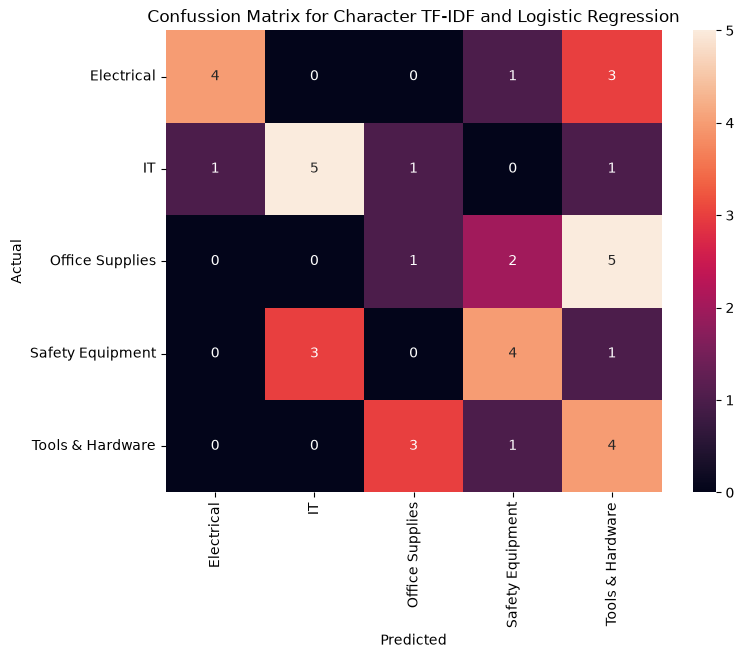

In [28]:
plt.figure(figsize=(8,6))

sns.heatmap(
    char_cm,
    annot=True,
    fmt='d',
    xticklabels=char_model.classes_,
    yticklabels=char_model.classes_
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confussion Matrix for Character TF-IDF and Logistic Regression')

plt.show()

In [29]:
char_feature_names = char_vectorizer.get_feature_names_out()

for i, category in enumerate(char_model.classes_):
    coefficients = char_model.coef_[i]

    top_indices = coefficients.argsort()[-15:][::-1]

    print(category)

    for index in top_indices:
        print(
            char_feature_names[index],
            round(coefficients[index], 3)
        )

Electrical
风机 0.366
电磁炉 0.366
波炉 0.366
磁炉 0.366
电磁 0.366
吹风 0.366
微波炉 0.366
微波 0.366
吹风机 0.366
空气 0.309
pu 0.285
el  0.282
abel  0.282
bel  0.282
lam 0.265
IT
商务 0.444
电脑 0.442
企业级 0.363
企业 0.363
业级 0.363
体机 0.304
一体机 0.304
一体 0.304
 m 0.291
多功能 0.277
功能 0.277
多功 0.277
pr 0.265
ro 0.258
up 0.257
Office Supplies
rtas 0.39
ertas 0.39
ert 0.39
kert 0.39
kerta 0.39
erta 0.39
资料册 0.367
书机 0.367
资料 0.367
面胶 0.367
长尾夹 0.367
长尾 0.367
便签 0.367
形针 0.367
文件 0.367
Safety Equipment
安全 0.747
灭火 0.503
at 0.493
灭火毯 0.374
火毯 0.374
急救 0.373
急救箱 0.373
救箱 0.373
ng 0.346
nga 0.341
ma 0.322
an 0.319
ga 0.303
pe 0.285
aru 0.273
Tools & Hardware
锤子 0.634
工具箱 0.366
工具 0.366
具箱 0.366
锁定 0.297
bo 0.293
0w 0.263
胶枪 0.259
热熔胶 0.259
熔胶枪 0.259
熔胶 0.259
热熔胶枪 0.259
热熔 0.259
10 0.237
pa 0.234


In [33]:
test_results = df.loc[x_test.index, ['language', 'product', 'category']].copy()

test_results['predicted'] = y_pred_char

test_results['correct'] = (
    test_results['category'] == test_results['predicted']
)

test_results.head(30)

,language,product,category,predicted,correct
185,zh,便携式投影仪,IT,Electrical,False
33,id,map tulang ukuran A4,Office Supplies,Safety Equipment,False
58,id,lampu sorot tanam untuk koridor,Electrical,Electrical,True
37,id,buku agenda ukran A5,Office Supplies,Tools & Hardware,False
79,id,baut kecil segi enam,Tools & Hardware,Office Supplies,False
124,zh,钢丝钳8寸,Tools & Hardware,Tools & Hardware,True
103,zh,防降噪耳罩,Safety Equipment,IT,False
116,zh,复合式洗眼器12L/min,Safety Equipment,Safety Equipment,True
106,zh,安全鞋耐200J冲击,Safety Equipment,Safety Equipment,True
101,zh,防护眼镜,Safety Equipment,Safety Equipment,True


In [34]:
language_accuracy = (
    test_results
    .groupby('language')['correct']
    .mean()
)

language_accuracy

language
id    0.444444
zh    0.454545
Name: correct, dtype: float64

In [38]:
from sklearn.metrics import f1_score

for language in ['id', 'zh']:
    subset = test_results[test_results['language'] == language]

    score = f1_score(
        subset['category'],
        subset['predicted'],
        average='macro'
    )

    print(f'{language} macro-f1: {score:.3f}')

id macro-f1: 0.448
zh macro-f1: 0.433


In [39]:
language_comparison = df.loc[
    x_test.index,
    ['language', 'category']
].copy()

language_comparison['word_prediction'] = y_pred
language_comparison['char_prediction'] = y_pred_char

language_comparison['word_correct'] = (
    language_comparison['category']
    == language_comparison['word_prediction']
)

language_comparison['char_correct'] = (
    language_comparison['category']
    == language_comparison['char_prediction']
)

In [40]:
language_comparison.groupby('language')[
    ['word_correct', 'char_correct']
].mean()

,word_correct,char_correct
language,,
id,0.666667,0.444444
zh,0.181818,0.454545
